In [1]:
import pandas as pd
import os
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models
import torch.nn as nn
from torch.utils.data import ConcatDataset
import torch.optim as optim
import random
from torch.utils.data import TensorDataset
from sklearn.cluster import KMeans
from torch.nn.utils import parameters_to_vector
from tqdm import tqdm
import time
import copy

dataset : https://www.kaggle.com/datasets/puneet6060/intel-image-classification?select=seg_train

Create the label files

In [2]:
dataset_train_path = '/Users/laurageneaulibourne/Downloads/S4/ia/exam/dataset/seg_train/seg_train'
dataset_test_path = '/Users/laurageneaulibourne/Downloads/S4/ia/exam/dataset/seg_test/seg_test'

classe = {'buildings' : 0, 'forest' : 1, 'glacier' : 2, 'mountain' : 3, 'sea' : 4, 'street' : 5}

for c in classe.keys():
    label_train = []
    label_test = []

    class_train_path = os.path.join(dataset_train_path, c)
    class_test_path = os.path.join(dataset_test_path, c)

    img_train_path = class_train_path +'/img'
    img_test_path = class_test_path+'/img'

    for imag in os.listdir(img_train_path):
        if not imag.startswith('.'): # avoid .DS_Store
            label_train.append({'image_name' : imag, 'label' : classe[c]})


    for imag in os.listdir(img_test_path):
        if not imag.startswith('.'):
            label_test.append({'image_name' : imag, 'label' : classe[c]})


    df_train = pd.DataFrame(label_train)
    df_train.to_csv(os.path.join(class_train_path, f"{classe[c]}_label_train.csv"), index=False)
    df_test = pd.DataFrame(label_test)
    df_test.to_csv(os.path.join(class_test_path, f"{classe[c]}_label_test.csv"), index=False)



create our dataset

In [3]:
#For each task we will do a classification on 2 classes, so we will create a new dataset with only 2 classes by merging our 2 directories and same thing for the file with the labels.

def task(A,B, idx):
    '''A and B are the 2 classes of the idx task'''
    path_img_A_train = os.path.join(dataset_train_path, A, 'img')
    path_img_B_train = os.path.join(dataset_train_path, B, 'img')
    path_img_AB_train = os.path.join(dataset_train_path, f'df_{A}_{B}', 'img')
    path_img_A_test = os.path.join(dataset_test_path, A, 'img')
    path_img_B_test = os.path.join(dataset_test_path, B, 'img')
    path_img_AB_test = os.path.join(dataset_test_path, f'df_{A}_{B}', 'img')

    #create the directory if it does not exist
    os.makedirs(path_img_AB_train, exist_ok=True)
    os.makedirs(path_img_AB_test, exist_ok=True)

    def move(init, final):
        for file in os.listdir(init):
            if not file.startswith('.'):
                source_file = os.path.join(init, file)
                dest_file = os.path.join(final, file)
                os.rename(source_file, dest_file)



    move(path_img_A_train, path_img_AB_train)
    move(path_img_B_train, path_img_AB_train)

    move(path_img_A_test, path_img_AB_test)
    move(path_img_B_test, path_img_AB_test)

    label_A_train = pd.read_csv(os.path.join(dataset_train_path, A, f"{classe[A]}_label_train.csv"))
    label_B_train = pd.read_csv(os.path.join(dataset_train_path, B, f"{classe[B]}_label_train.csv"))
    label_A_train['label'] = 0
    label_B_train['label'] = 1
    label_AB_train = pd.concat([label_A_train, label_B_train], ignore_index=True)
    label_AB_train['task_id'] = idx
    label_AB_train.to_csv(os.path.join(dataset_train_path,f'df_{A}_{B}', 'label_train.csv'), index=False)



    label_A_test = pd.read_csv(os.path.join(dataset_test_path, A, f"{classe[A]}_label_test.csv"))
    label_B_test = pd.read_csv(os.path.join(dataset_test_path, B, f"{classe[B]}_label_test.csv"))
    label_A_test['label'] = 0
    label_B_test['label'] = 1
    label_AB_test = pd.concat([label_A_test, label_B_test], ignore_index=True)
    label_AB_test['task_id'] = idx
    label_AB_test.to_csv(os.path.join(dataset_test_path, f'df_{A}_{B}', 'label_test.csv'), index=False)

    return (path_img_AB_train, path_img_AB_test, label_AB_train, label_AB_test)

path_img_AB_train, path_img_AB_test, label_AB_train, label_AB_test = task('buildings', 'street', 0)
path_img_CD_train, path_img_CD_test, label_CD_train, label_CD_test = task('glacier', 'mountain', 1)

Repartition of the dataset through the 6 classes

In [4]:

def repartition(label_train, label_test, classe_0, classe_1):

    train_tot = len(label_train) # total number of images in the train for this task
    test_tot  = len(label_test) # total number of images in the test for this task

    nb_0_train = (label_train['label'] == 0).sum() #number of images in the train for the class 0
    nb_1_train = (label_train['label'] == 1).sum() #number of images in the train for the class 1
    nb_0_test  = (label_test['label'] == 0).sum() #number of images in the test for the class 0
    nb_1_test  = (label_test['label'] == 1).sum() #number of images in the test for the class 1

    print(f"Task : {label_train['task_id'].iloc[0]} \n")
    print(f" Total images in the train for the task {classe_0}/{classe_1} : {train_tot}")
    print(f" Pourcentage of images in the train for the class {classe_0} : {nb_0_train * 100/ train_tot}%")
    print(f" Pourcentage of images in the train for the class {classe_1} : {nb_1_train * 100/ train_tot}%")

    print(f" Total images in the test for the task {classe_0}/{classe_1} : {test_tot}")
    print(f" Pourcentage of images in the test for the class {classe_0} : {nb_0_test * 100/ test_tot}%")
    print(f" Pourcentage of images in the test for the class {classe_1} : {nb_1_test * 100/ test_tot}% \n")


repartition(label_AB_train, label_AB_test, 'buildings', 'street')
repartition(label_CD_train, label_CD_test, 'glacier', 'mountain')



Task : 0 

 Total images in the train for the task buildings/street : 4573
 Pourcentage of images in the train for the class buildings : 47.91165536846709%
 Pourcentage of images in the train for the class street : 52.08834463153291%
 Total images in the test for the task buildings/street : 938
 Pourcentage of images in the test for the class buildings : 46.588486140724946%
 Pourcentage of images in the test for the class street : 53.411513859275054% 

Task : 1 

 Total images in the train for the task glacier/mountain : 4916
 Pourcentage of images in the train for the class glacier : 48.901545972335235%
 Pourcentage of images in the train for the class mountain : 51.098454027664765%
 Total images in the test for the task glacier/mountain : 1078
 Pourcentage of images in the test for the class glacier : 51.298701298701296%
 Pourcentage of images in the test for the class mountain : 48.701298701298704% 



In [5]:
class CustomImageDataset(Dataset):

    def __init__(self, annotations_file, img_dir, portion, img_transform=None): # portion is the pourcentage of the dataset that we will keep in order to avoid catastrophic forgetting during the new task.

        self.img_dir = img_dir
        self.img_transform = img_transform

        if portion < 1.0:
            self.img_labels = annotations_file.sample(frac=portion, random_state=42).reset_index(drop=True)
        else:
            self.img_labels = annotations_file

    def __len__(self): #Return the number of samples in the dataset.
        return len(self.img_labels)

    def __getitem__(self, idx): #For a given index, it returns the sample (image, label) associated to it.

        # Get the file path of the image by combining the directory and the image filename from the labels DataFrame
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])

        # Read the image from the specified file path and convert it to a tensor
        image = Image.open(img_path)

        # Retrieve the corresponding label for the image from the labels DataFrame
        label = self.img_labels.iloc[idx, 1]

        task = self.img_labels.iloc[idx, 2]

        # If a transform function is provided, apply it to the image
        if self.img_transform:
            image = self.img_transform(image)

        # Return the transformed image and label and task as a triplet
        return image, label, task


In [6]:
# List of transformations that will be applied to images
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])


In [7]:

dataset_train_AB_full = CustomImageDataset(annotations_file= label_AB_train, img_dir = path_img_AB_train, portion = 1 , img_transform=transform)
dataset_test_AB_full = CustomImageDataset(annotations_file= label_AB_test, img_dir = path_img_AB_test, portion = 1 , img_transform=transform)

train_dataloader_AB_full = DataLoader(dataset_train_AB_full, batch_size=64, shuffle=True)
test_dataloader_AB_full= DataLoader(dataset_test_AB_full, batch_size=64, shuffle=True)


portion = 0.5 #portion of the dataset of the previous dataset we want to keep for avoiding the catastrophic forgetting during the new task.



dataset_train_AB_part = CustomImageDataset(annotations_file= label_AB_train, img_dir = path_img_AB_train, portion = portion , img_transform=transform)
dataset_test_AB_part = CustomImageDataset(annotations_file= label_AB_test, img_dir = path_img_AB_test, portion = portion, img_transform=transform)

train_dataloader_AB_part = DataLoader(dataset_train_AB_part, batch_size=64, shuffle=True)
test_dataloader_AB_part= DataLoader(dataset_test_AB_part, batch_size=64,  shuffle=True)





dataset_train_CD_full = CustomImageDataset(annotations_file= label_CD_train, img_dir = path_img_CD_train, portion = 1 , img_transform=transform)
dataset_test_CD_full = CustomImageDataset(annotations_file= label_CD_test, img_dir = path_img_CD_test, portion = 1, img_transform=transform)

train_dataloader_CD_full = DataLoader(dataset_train_CD_full, batch_size=64, shuffle=True)
test_dataloader_CD_full= DataLoader(dataset_test_CD_full, batch_size=64, shuffle=True)






dataset_train_ABCD = ConcatDataset([dataset_train_AB_part, dataset_train_CD_full])
dataset_test_ABCD = ConcatDataset([dataset_test_AB_part, dataset_test_CD_full])

train_dataloader_ABCD = DataLoader(dataset_train_ABCD, batch_size=64, shuffle=True)
test_dataloader_ABCD= DataLoader(dataset_test_ABCD, batch_size=64, shuffle=True)


In [ ]:

dataset_train_AB_part10 = CustomImageDataset(annotations_file= label_AB_train, img_dir = path_img_AB_train, portion = 0.1 , img_transform=transform)
dataset_test_AB_part10 = CustomImageDataset(annotations_file= label_AB_test, img_dir = path_img_AB_test, portion = 0.1, img_transform=transform)

train_dataloader_AB_part10 = DataLoader(dataset_train_AB_part10, batch_size=64, shuffle=True)
test_dataloader_AB_part10= DataLoader(dataset_test_AB_part10, batch_size=64,  shuffle=True)



dataset_train_ABCD10= ConcatDataset([dataset_test_AB_part10, dataset_test_CD_full])

train_dataloader_ABCD10 = DataLoader(dataset_train_ABCD10, batch_size=64, shuffle=True)
test_dataloader_ABCD10 = DataLoader(dataset_test_ABCD, batch_size=64, shuffle=True)


In [8]:
def train_loop_basic(dataloader, model, loss, optimizer, num_epochs, device):
    size = len(dataloader.dataset)
    model = model.to(device)
    model.train()

    for epoch in range(num_epochs):

        epoch_loss = 0.0
        dic_acc = {"A_true": 0,"A_tot": 0,  "B_true": 0, "B_tot" : 0}  # accuracy dictionary for each class

        for image, label, _ in dataloader:

            #put image and label on the same device
            image= image.to(device)
            label= label.to(device)

            optimizer.zero_grad()  # Set gradient to zero

            # Compute prediction and loss
            pred = model(image)

            batch_loss = loss(pred, label)
            epoch_loss += batch_loss.item() * image.size(0)

            pred_class = pred.argmax(dim=1)
            pred_classA = (pred_class == 0)
            label_A = (label == 0)
            dic_acc["A_true"] += (pred_classA & label_A).sum().item() #when the prediction is equal the ground truth
            dic_acc["A_tot"] += label_A.sum().item()

            pred_classB = (pred_class == 1)
            label_B = (label == 1)
            dic_acc["B_true"] += (pred_classB & label_B).sum().item()
            dic_acc["B_tot"] += label_B.sum().item()

            # Backpropagation
            batch_loss.backward()
            optimizer.step()

        epoch_loss = epoch_loss / size


        print(f'Epoch {epoch+1}/{num_epochs}, Total Mean Loss: {epoch_loss}, '
              f'Accuracy A: {(dic_acc["A_true"] * 100 / dic_acc["A_tot"] if dic_acc["A_tot"] > 0 else 0.0)} %, '
              f'B: {(dic_acc["B_true"] * 100 / dic_acc["B_tot"] if dic_acc["B_tot"] > 0 else 0.0)} %, '
    )




In [9]:
def test_loop_basic(dataloader, model, loss, device):
    size = len(dataloader.dataset)
    model = model.to(device)
    model.eval()

    with torch.no_grad():

        test_loss = 0.0
        dic_acc = {"A_true": 0,"A_tot": 0,  "B_true": 0, "B_tot" : 0, "C_true": 0, "C_tot" : 0, "D_true": 0, "D_tot": 0}  # accuracy dictionary for each class

        for image, label, task in dataloader:

            #put image and label on the same device
            image= image.to(device)
            label= label.to(device)
            task = task.to(device)

            # Compute prediction and loss
            pred = model(image)

            batch_loss = loss(pred, label)
            test_loss += batch_loss.item() * image.size(0)
            
            

            pred_class = pred.argmax(dim=1)
            
            #Claculate the accuracy 
            pred_class0_task0= (pred_class == 0) & (task==0)
            label0_task0 = (label == 0) & (task==0)
            dic_acc["A_true"] += (pred_class0_task0 & label0_task0).sum().item()
            dic_acc["A_tot"] += label0_task0.sum().item()
          
            pred_class1_task0= (pred_class == 1) & (task==0)
            label1_task0 = (label == 1) & (task==0)
            dic_acc["B_true"] += (pred_class1_task0 & label1_task0).sum().item()
            dic_acc["B_tot"] += label1_task0.sum().item()      

            pred_class0_task1= (pred_class == 0) & (task==1)
            label0_task1 = (label == 0) & (task==1)
            dic_acc["C_true"] += (pred_class0_task1 & label0_task1).sum().item()
            dic_acc["C_tot"] += label0_task1.sum().item()
          
            pred_class1_task1= (pred_class == 1) & (task==1)
            label1_task1 = (label == 1) & (task==1)
            dic_acc["D_true"] += (pred_class1_task1 & label1_task1).sum().item()
            dic_acc["D_tot"] += label1_task1.sum().item()    

        test_loss = test_loss / size


        print(f'Test Loss: {test_loss}, '
            f'Accuracy A: {(dic_acc["A_true"] * 100 / dic_acc["A_tot"] if dic_acc["A_tot"] > 0 else 0.0)} %, '
            f'B: {(dic_acc["B_true"] * 100 / dic_acc["B_tot"] if dic_acc["B_tot"] > 0 else 0.0)} %, '
            f'C: {(dic_acc["C_true"] * 100 / dic_acc["C_tot"] if dic_acc["C_tot"] > 0 else 0.0)} %, '
            f'D: {(dic_acc["D_true"] * 100 / dic_acc["D_tot"] if dic_acc["D_tot"] > 0 else 0.0)} %'
        )


In [10]:
basic_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # we consider a pretrained model
num_features = basic_model.fc.in_features
basic_model.fc = nn.Linear(num_features, 2) #2 classes so 2 neurons

In [11]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
    
    
loss = nn.CrossEntropyLoss()
optimizer_basic = optim.SGD(basic_model.parameters(), lr=0.001, momentum=0.9)
num_epochs = 10

A = buildings ; B = street

In [12]:
%%time
train_loop_basic(dataloader = train_dataloader_AB_full , model = basic_model, loss = loss, optimizer = optimizer_basic, num_epochs = num_epochs, device = device)

Epoch 1/10, Total Mean Loss: 0.3136600330423115, Accuracy A: 83.38658146964856 %, B: 87.74139378673384 %, 
Epoch 2/10, Total Mean Loss: 0.13419868022027487, Accuracy A: 94.52304883614788 %, B: 95.29806884970613 %, 
Epoch 3/10, Total Mean Loss: 0.08888844096788348, Accuracy A: 96.6225467822912 %, B: 97.14525608732158 %, 
Epoch 4/10, Total Mean Loss: 0.05936010119177543, Accuracy A: 97.94614331355545 %, B: 98.48866498740554 %, 
Epoch 5/10, Total Mean Loss: 0.034922414637487825, Accuracy A: 99.13281606572342 %, B: 99.62216624685138 %, 
Epoch 6/10, Total Mean Loss: 0.024760104241100114, Accuracy A: 99.40666362391602 %, B: 99.66414777497901 %, 
Epoch 7/10, Total Mean Loss: 0.019848300113527825, Accuracy A: 99.40666362391602 %, B: 99.74811083123426 %, 
Epoch 8/10, Total Mean Loss: 0.016473368829449817, Accuracy A: 99.68051118210863 %, B: 99.79009235936188 %, 
Epoch 9/10, Total Mean Loss: 0.014036772395090073, Accuracy A: 99.90871748060246 %, B: 99.8320738874895 %, 
Epoch 10/10, Total Mean Lo

In [13]:
%%time
test_loop_basic(dataloader = test_dataloader_AB_full  , model = basic_model, loss = loss,device = device)

Test Loss: 0.19315206159406634, Accuracy A: 93.13501144164759 %, B: 93.01397205588822 %, C: 0.0 %, D: 0.0 %
CPU times: user 530 ms, sys: 207 ms, total: 737 ms
Wall time: 1.74 s


A= glacier ; B = mountain

In [14]:
%%time
train_loop_basic(dataloader = train_dataloader_CD_full  , model = basic_model, loss = loss, optimizer = optimizer_basic, num_epochs = num_epochs, device = device)

Epoch 1/10, Total Mean Loss: 0.5325763779408181, Accuracy A: 79.70049916805324 %, B: 80.45382165605096 %, 
Epoch 2/10, Total Mean Loss: 0.17543564250645743, Accuracy A: 93.17803660565724 %, B: 93.51114649681529 %, 
Epoch 3/10, Total Mean Loss: 0.0921970077944151, Accuracy A: 97.25457570715474 %, B: 97.4124203821656 %, 
Epoch 4/10, Total Mean Loss: 0.05892101441266771, Accuracy A: 98.50249584026622 %, B: 98.76592356687898 %, 
Epoch 5/10, Total Mean Loss: 0.02678220684240755, Accuracy A: 99.58402662229618 %, B: 99.72133757961784 %, 
Epoch 6/10, Total Mean Loss: 0.023555858145589942, Accuracy A: 99.79201331114808 %, B: 99.72133757961784 %, 
Epoch 7/10, Total Mean Loss: 0.01666989436780805, Accuracy A: 99.79201331114808 %, B: 99.88057324840764 %, 
Epoch 8/10, Total Mean Loss: 0.014583315594959928, Accuracy A: 99.83361064891847 %, B: 99.80095541401273 %, 
Epoch 9/10, Total Mean Loss: 0.011543042974832995, Accuracy A: 99.87520798668885 %, B: 99.80095541401273 %, 
Epoch 10/10, Total Mean Loss

In [15]:
%%time
test_loop_basic(dataloader = test_dataloader_CD_full  , model = basic_model, loss = loss,device = device)

Test Loss: 0.40498408072512315, Accuracy A: 0.0 %, B: 0.0 %, C: 89.33092224231464 %, D: 87.23809523809524 %
CPU times: user 608 ms, sys: 206 ms, total: 813 ms
Wall time: 2.24 s


A = buildings ; B = street; C= glacier ; D = mountain

In [16]:
%%time
test_loop_basic(dataloader = test_dataloader_ABCD  , model = basic_model, loss = loss,device = device)

Test Loss: 0.5423525652734402, Accuracy A: 93.13304721030043 %, B: 52.54237288135593 %, C: 89.33092224231464 %, D: 87.23809523809524 %
CPU times: user 829 ms, sys: 284 ms, total: 1.11 s
Wall time: 2.96 s


In [17]:
class rehearsal(nn.Module):
# Constructor method to initialize layers of the network def __init__(self):
        def __init__(self,num_classe=2):
                super().__init__()
                self.num_classe = num_classe
                self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) 
                self.num_features = self.model.fc.in_features
                self.model.fc = nn.Identity()
                self.heads = nn.ModuleDict()

        def add_task(self, num_task):
                num_task = str(num_task)
                if num_task not in self.heads:
                        self.heads[num_task] = nn.Linear(self.num_features, self.num_classe) #2 tasks with 2 classes

        # Forward pass of the network
        def forward(self, x, num_task):
                features = self.model(x)  
                outputs = torch.zeros(x.size(0), self.num_classe, device=x.device)

                for t in torch.unique(num_task):
                        t_str = str(t.item())
                        if t_str not in self.heads:
                                raise ValueError(f"Task {t_str} not found in the model.")
                        mask = (num_task == t)
                        outputs[mask] = self.heads[t_str](features[mask])

                return outputs


In [18]:
def train_loop_rehearsal(dataloader, model, loss, optimizer, num_epochs, device):

    model = model.to(device)
    model.train()

    for epoch in range(num_epochs):

        epoch_lossAB = 0.0
        epoch_lossCD = 0.0
        epoch_loss_tot = 0.0
        dic_acc = {"A_true": 0,"A_tot": 0,  "B_true": 0, "B_tot" : 0,  "C_true": 0, "C_tot" : 0, "D_true": 0, "D_tot": 0}  # accuracy dictionary for each class


        for image, label, task in dataloader:


            batch_lossAB = 0.0
            batch_lossCD = 0.0
            batch_loss_tot = 0.0
            #put image and label on the same device
            image= image.to(device)
            label= label.to(device)
            task = task.to(device)

            optimizer.zero_grad()  # Set gradient to zero

            # Compute prediction and loss
            pred = model(image, task)

            mask_AB = (task == 0)
            mask_CD = (task == 1)

            if mask_AB.sum() > 0: # at least one image from the 1st task in the batch
                pred_AB = pred[mask_AB]
                label_AB = label[mask_AB]

                batch_lossAB = loss(pred_AB, label_AB)
                epoch_lossAB += batch_lossAB.item()* label_AB.size(0)

                # For each image, choose the class with the higher score
                pred_classAB = pred_AB.argmax(dim=1)
                pred_classA = (pred_classAB == 0)
                label_A = (label_AB == 0)
                dic_acc["A_true"] += (pred_classA & label_A).sum().item()
                dic_acc["A_tot"] += label_A.sum().item()

                pred_classB = (pred_classAB == 1)
                label_B = (label_AB == 1)
                dic_acc["B_true"] += (pred_classB & label_B).sum().item()
                dic_acc["B_tot"] += label_B.sum().item()


            if mask_CD.sum() > 0: # at least one image from the 2nd task in the batch
                pred_CD = pred[mask_CD]
                label_CD = label[mask_CD]

                batch_lossCD = loss(pred_CD, label_CD)
                epoch_lossCD += batch_lossCD.item()* label_CD.size(0)

                pred_classCD = pred_CD.argmax(dim=1)
                pred_classC = (pred_classCD == 0)
                label_C = (label_CD == 0)
                dic_acc["C_true"] += (pred_classC & label_C).sum().item()
                dic_acc["C_tot"] += label_C.sum().item()

                pred_classD = (pred_classCD == 1)
                label_D = (label_CD == 1)
                dic_acc["D_true"] += (pred_classD & label_D).sum().item()
                dic_acc["D_tot"] += label_D.sum().item()


            batch_loss_tot = batch_lossAB + batch_lossCD
            epoch_loss_tot += batch_loss_tot.item()

            # Backpropagation
            batch_loss_tot.backward()
            optimizer.step()

        nb_AB = dic_acc["A_tot"] + dic_acc["B_tot"]
        nb_CD = dic_acc["C_tot"] + dic_acc["D_tot"]

        epoch_lossAB = epoch_lossAB / nb_AB
        if nb_CD > 0:
            epoch_lossCD = epoch_lossCD / nb_CD
        else :
            epoch_lossCD = 0.0
        epoch_loss = (epoch_lossAB + epoch_lossCD)


        print(f'Epoch {epoch+1}/{num_epochs}, Total Mean Loss: {epoch_loss}, 1st task Loss: {epoch_lossAB}, 2nd task Loss: {epoch_lossCD}, '
              f'Accuracy A: {(dic_acc["A_true"] * 100 / dic_acc["A_tot"] if dic_acc["A_tot"] > 0 else 0.0)} %, '
              f'B: {(dic_acc["B_true"] * 100 / dic_acc["B_tot"] if dic_acc["B_tot"] > 0 else 0.0)} %, '
              f'C: {(dic_acc["C_true"] * 100 / dic_acc["C_tot"] if dic_acc["C_tot"] > 0 else 0.0)} %, '
              f'D: {(dic_acc["D_true"] * 100 / dic_acc["D_tot"] if dic_acc["D_tot"] > 0 else 0.0)} %')




In [19]:
def test_loop_rehearsal(dataloader, model, loss, device):

    model = model.to(device)
    model.eval()
    loss_test = 0.0
    loss_testAB = 0.0
    loss_testCD = 0.0

    dic_acc = {"A_true": 0,"A_tot": 0,  "B_true": 0, "B_tot" : 0,  "C_true": 0, "C_tot" : 0, "D_true": 0, "D_tot": 0}  # accuracy dictionary for each class

    with torch.no_grad():


        for image, label, task in dataloader:

            batch_lossAB = 0.0
            batch_lossCD = 0.0
            batch_loss_tot = 0.0

            #put image and label on the same device
            image= image.to(device)
            label= label.to(device)

            # Compute prediction and loss
            pred = model(image, task)

            mask_AB = (task == 0)
            mask_CD = (task == 1)

            if mask_AB.sum() > 0: # at least one image from the 1st task in the batch
                pred_AB = pred[mask_AB]
                label_AB = label[mask_AB]

                batch_lossAB = loss(pred_AB, label_AB)
                loss_testAB += batch_lossAB.item()* label_AB.size(0)

                # For each image, choose the class with the higher score
                pred_classAB = pred_AB.argmax(dim=1)
                pred_classA = (pred_classAB == 0)
                label_A = (label_AB == 0)
                dic_acc["A_true"] += (pred_classA & label_A).sum().item()
                dic_acc["A_tot"] += label_A.sum().item()

                pred_classB = (pred_classAB == 1)
                label_B = (label_AB == 1)
                dic_acc["B_true"] += (pred_classB & label_B).sum().item()
                dic_acc["B_tot"] += label_B.sum().item()



            if mask_CD.sum() > 0: # at least one image from the 2nd task in the batch
                pred_CD = pred[mask_CD]
                label_CD = label[mask_CD]

                batch_lossCD = loss(pred_CD, label_CD)
                loss_testCD += batch_lossCD.item()* label_CD.size(0)

                pred_classCD = pred_CD.argmax(dim=1)
                pred_classC = (pred_classCD == 0)
                label_C = (label_CD == 0)
                dic_acc["C_true"] += (pred_classC & label_C).sum().item()
                dic_acc["C_tot"] += label_C.sum().item()

                pred_classD = (pred_classCD == 1)
                label_D = (label_CD == 1)
                dic_acc["D_true"] += (pred_classD & label_D).sum().item()
                dic_acc["D_tot"] += label_D.sum().item()

        nb_AB = dic_acc["A_tot"] + dic_acc["B_tot"]
        nb_CD = dic_acc["C_tot"] + dic_acc["D_tot"]

        if nb_AB > 0:
            loss_testAB = loss_testAB / nb_AB
        else:
            loss_testAB = 0.0
        if nb_CD > 0:
            loss_testCD = loss_testCD / nb_CD
        else:
            loss_testCD = 0.0

        loss_test =  loss_testAB + loss_testCD


        print(f'Total Mean Loss per images: {loss_test}, 1st task Loss: {loss_testAB}, 2nd task Loss: {loss_testCD}',
              f'Accuracy A: {(dic_acc["A_true"] * 100 / dic_acc["A_tot"] if dic_acc["A_tot"] > 0 else 0.0)} %, '
              f'B: {(dic_acc["B_true"] * 100 / dic_acc["B_tot"] if dic_acc["B_tot"] > 0 else 0.0)} %, '
              f'C: {(dic_acc["C_true"] * 100 / dic_acc["C_tot"] if dic_acc["C_tot"] > 0 else 0.0)} %, '
              f'D: {(dic_acc["D_true"] * 100 / dic_acc["D_tot"] if dic_acc["D_tot"] > 0 else 0.0)} %')
        
    return loss_testAB, dic_acc



In [20]:
model_rehearsal = rehearsal()
model_rehearsal.add_task(0)
model_rehearsal.add_task(1)
optimizer_rehearsal = optim.SGD(model_rehearsal.parameters(), lr=0.001, momentum=0.9)

In [21]:
%%time
train_loop_rehearsal(train_dataloader_AB_full , model_rehearsal, loss, optimizer_rehearsal, num_epochs, device)

Epoch 1/10, Total Mean Loss: 0.3029155243109124, 1st task Loss: 0.3029155243109124, 2nd task Loss: 0.0, Accuracy A: 83.97991784573254 %, B: 88.58102434928631 %, C: 0.0 %, D: 0.0 %
Epoch 2/10, Total Mean Loss: 0.1367010627403813, 1st task Loss: 0.1367010627403813, 2nd task Loss: 0.0, Accuracy A: 94.47740757644911 %, B: 95.59193954659949 %, C: 0.0 %, D: 0.0 %
Epoch 3/10, Total Mean Loss: 0.09040788113773554, 1st task Loss: 0.09040788113773554, 2nd task Loss: 0.0, Accuracy A: 95.93792788680967 %, B: 97.48110831234257 %, C: 0.0 %, D: 0.0 %
Epoch 4/10, Total Mean Loss: 0.056752403869755726, 1st task Loss: 0.056752403869755726, 2nd task Loss: 0.0, Accuracy A: 98.1743496120493 %, B: 98.53064651553316 %, C: 0.0 %, D: 0.0 %
Epoch 5/10, Total Mean Loss: 0.03529117592782916, 1st task Loss: 0.03529117592782916, 2nd task Loss: 0.0, Accuracy A: 98.90460976722957 %, B: 99.37027707808564 %, C: 0.0 %, D: 0.0 %
Epoch 6/10, Total Mean Loss: 0.024159658785356284, 1st task Loss: 0.024159658785356284, 2nd t

In [22]:
%%time
test_loop_rehearsal(test_dataloader_AB_full, model_rehearsal, loss, device)

Total Mean Loss per images: 0.19188053724862364, 1st task Loss: 0.19188053724862364, 2nd task Loss: 0.0 Accuracy A: 92.21967963386727 %, B: 94.41117764471058 %, C: 0.0 %, D: 0.0 %
CPU times: user 562 ms, sys: 222 ms, total: 784 ms
Wall time: 2 s


(0.19188053724862364,
 {'A_true': 403,
  'A_tot': 437,
  'B_true': 473,
  'B_tot': 501,
  'C_true': 0,
  'C_tot': 0,
  'D_true': 0,
  'D_tot': 0})

In [23]:
%%time
train_loop_rehearsal(train_dataloader_ABCD , model_rehearsal, loss, optimizer_rehearsal, num_epochs, device)

Epoch 1/10, Total Mean Loss: 0.4126314700056534, 1st task Loss: 0.04369977724215721, 2nd task Loss: 0.3689316927634962, Accuracy A: 98.35315645013723 %, B: 98.65884325230512 %, C: 84.40099833610648 %, D: 83.95700636942675 %
Epoch 2/10, Total Mean Loss: 0.2021342561366281, 1st task Loss: 0.011232286235374624, 2nd task Loss: 0.1909019699012535, Accuracy A: 100.0 %, B: 99.91617770326907 %, C: 91.26455906821964 %, D: 93.9092356687898 %
Epoch 3/10, Total Mean Loss: 0.11889515767815245, 1st task Loss: 0.004452825811691989, 2nd task Loss: 0.11444233186646047, Accuracy A: 100.0 %, B: 99.91617770326907 %, C: 95.17470881863561 %, D: 96.65605095541402 %
Epoch 4/10, Total Mean Loss: 0.06432515928850197, 1st task Loss: 0.003823786637702791, 2nd task Loss: 0.060501372650799176, Accuracy A: 99.90850869167429 %, B: 99.91617770326907 %, C: 97.75374376039933 %, D: 98.72611464968153 %
Epoch 5/10, Total Mean Loss: 0.036668264692127264, 1st task Loss: 0.0029140295062163924, 2nd task Loss: 0.033754235185910

In [24]:
%%time
test_loop_rehearsal(test_dataloader_ABCD, model_rehearsal, loss, device)

Total Mean Loss per images: 0.6241800818138086, 1st task Loss: 0.24548113083482773, 2nd task Loss: 0.3786989509789809 Accuracy A: 92.70386266094421 %, B: 93.22033898305085 %, C: 84.99095840867993 %, D: 93.9047619047619 %
CPU times: user 1.18 s, sys: 595 ms, total: 1.78 s
Wall time: 5.61 s


(0.24548113083482773,
 {'A_true': 216,
  'A_tot': 233,
  'B_true': 220,
  'B_tot': 236,
  'C_true': 470,
  'C_tot': 553,
  'D_true': 493,
  'D_tot': 525})

A-GEM with better samples

In [26]:
def project_gradient(g, g_ref):

    dot_product = torch.dot(g, g_ref)
    if dot_product >= 0:
        return g 
    else:
    #g_update = g - ( (g^t * g_ref) / (g_ref^T*g_ref) ) * g_ref but here we don't apply the transpose because g is already a vector
        dot_product_g_ref = torch.dot(g_ref, g_ref) + 1e-10 # to avoid division by zero
        g_update = g - (dot_product / dot_product_g_ref) * g_ref
        return g_update

In [27]:

def train_loop_gradient_selection_task0(model, dataloader, loss_fn, num_epoch, optimizer, device):

    model.train()
    model = model.to(device)
    
    #data we want to store all the images with the norm of their gradient in memory to select the one with the higher norm gradient to use it during the 2nd task and thus avoid forgetting 
    data_class0 = [] #(image, gradient norm)
    data_class1 = [] #(image, gradient norm)

    for epoch in range(num_epoch):
 
        epoch_loss = 0.0
            
        for images, labels, tasks in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            tasks = tasks.to(device)
            
            optimizer.zero_grad()
            
            if (epoch < num_epoch - 1):
                outputs = model(images, tasks)
                
                loss_batch = loss_fn(outputs, labels)
            
                loss_batch.backward()
                optimizer.step()
                epoch_loss += loss_batch.item() * len(tasks) #if the last batch has a different size from the others 
                
            
            
            else: # We will check the gradient norms only for the last epoch and for each image
                
                for i in range(images.size(0)):
                    optimizer.zero_grad()
                    image_i = images[i].unsqueeze(0)
                    label_i = labels[i].unsqueeze(0)
                    task_i = tasks[i].unsqueeze(0)
                    
                    pred_i = model(image_i, task_i)
                    loss_i = loss_fn(pred_i, label_i)
                    
                    loss_i.backward()
                
                    #calculate the norm of the gradient 
                    sum_squar = 0.0
                    for param in model.heads.parameters():
                        if param.grad is not None:
                            sum_squar += torch.sum(param.grad ** 2).item()
                    norm = sum_squar ** 0.5
                    
                    img = images[i].cpu().detach()
                    lbl= labels[i].cpu().detach()
                    
                    if lbl == 0:
                        data_class0.append((img,norm ))
                    elif lbl== 1:
                        data_class1.append((img,norm ))

                optimizer.zero_grad()
                outputs = model(images, tasks)
                loss_batch = loss_fn(outputs, labels) 
                loss_batch.backward()
                optimizer.step()
                epoch_loss += loss_batch.item()* len(tasks)
        epoch_loss = epoch_loss/len(dataloader.dataset) # we divide by the total number of images in the dataset 
                    
                    
        print(f"Epoch {epoch+1}/{num_epoch}, Loss : {epoch_loss}")
        
    return data_class0, data_class1




In [28]:
model_agem_grad_select = rehearsal()
model_agem_grad_select.add_task(0)
model_agem_grad_select.add_task(1)
optimizer_agem_grad_select= optim.SGD(model_agem_grad_select.parameters(), lr=0.001, momentum=0.9)

In [29]:
data_class_0, data_class_1 = train_loop_gradient_selection_task0(model_agem_grad_select, train_dataloader_AB_full ,loss, num_epochs, optimizer_agem_grad_select, device) 

Epoch 1/10, Loss : 0.3103143943755965
Epoch 2/10, Loss : 0.13937867284081787
Epoch 3/10, Loss : 0.0860306165286391
Epoch 4/10, Loss : 0.05497646230936259
Epoch 5/10, Loss : 0.04098387615151969
Epoch 6/10, Loss : 0.025623320382134857
Epoch 7/10, Loss : 0.01725722045169053
Epoch 8/10, Loss : 0.01679371397762272
Epoch 9/10, Loss : 0.008759645509323614
Epoch 10/10, Loss : 0.009077936008121682


In [30]:
weights_AB = copy.deepcopy(model_agem_grad_select.state_dict()) # after we are going to train the task 1 on different parameters so we don't want to train again on the task 0 which is common for all the other models with different parameters for the parameters concern the train on the task 1 and not 0 

In [31]:

def select_k_percent(data_class0, data_class1, k_percent=0.05):
    #Take 2 lists of couples (image, norm_gradient), sort the couples by keeping the images with the highest gradient and then select k% of the first sorted elements of the 2 lists ad put the associated image in one list with the couples ( image, label)
    nb_0 = int(len(data_class0) * k_percent) # number of images of the 1st class we are going to store in memory 
    nb_1 = int(len(data_class1) * k_percent) # number of images of the 2nd class we are going to store in memory 
    data_k_percent = []
    
    data_class0.sort(key=lambda x: x[1], reverse=True) #reverse = True for the descending" order 
    
    for couple in data_class0[:nb_0]:
        data_k_percent.append((couple[0], 0))
      
      
    data_class1.sort(key=lambda x: x[1], reverse=True) 
    
    for couple in data_class1[:nb_1]:
        data_k_percent.append((couple[0], 1))               
                     
                     
    return data_k_percent

In [32]:

def train_loop_gradient_selection_task_0_1(model, dataloader, data_k_percent, loss_fn, num_epoch, optimizer, device, batch_size):
    start_time = time.time()
    model.train()
    model = model.to(device)

    for epoch in range(num_epoch):

        epoch_loss_task0 = 0.0
        epoch_loss_task1 = 0.0
        total_mem_images_seen = 0  
        
        dic_acc = {"A_true": 0, "A_tot": 0, "B_true": 0, "B_tot": 0, "C_true": 0, "C_tot": 0, "D_true": 0, "D_tot": 0}

        for images, labels, tasks in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            tasks = tasks.to(device)

            optimizer.zero_grad()
            outputs_task1 = model(images, tasks)
            loss_task1 = loss_fn(outputs_task1, labels)
            loss_task1.backward()
            
            epoch_loss_task1 += loss_task1.item() * images.size(0)
   
        
            pred_class_t1 = outputs_task1.argmax(dim=1)
            
            mask_C = (labels == 0)
            dic_acc["C_true"] += (pred_class_t1[mask_C] == 0).sum().item()
            dic_acc["C_tot"] += mask_C.sum().item()
            
            mask_D = (labels == 1)
            dic_acc["D_true"] += (pred_class_t1[mask_D] == 1).sum().item()
            dic_acc["D_tot"] += mask_D.sum().item()
            
            head1_grad_saved = model.heads["1"].weight.grad.clone()
            head1_bias_saved = model.heads["1"].bias.grad.clone()
            
            for param in model.parameters():
                if param.grad is None and param.requires_grad:
                    param.grad = torch.zeros_like(param.data)
            
            g_new = [] 
            for name, param in model.named_parameters():
                if param.grad is not None and "heads" not in name:
                    g_new.append(param.grad.view(-1))
            g_new = torch.cat(g_new)


            if len(data_k_percent) >= batch_size:
                batch_task0 = random.sample(data_k_percent, batch_size)
            else: 
                raise ValueError("the size of the batch for the task 0 can not be higher than the truncked dataset itself")
            
            mem_images = torch.stack([couple[0] for couple in batch_task0]).to(device)
            mem_labels = torch.tensor([couple[1] for couple in batch_task0]).to(device)
            mem_tasks = torch.zeros_like(mem_labels).to(device) 

            model.zero_grad()
            
            outputs_mem = model(mem_images, mem_tasks)
            loss_mem = loss_fn(outputs_mem, mem_labels)
            loss_mem.backward()
            
            epoch_loss_task0 += loss_mem.item() * mem_images.size(0)
            total_mem_images_seen += mem_images.size(0)

            pred_class_t0 = outputs_mem.argmax(dim=1)
            
            mask_A = (mem_labels == 0)
            dic_acc["A_true"] += (pred_class_t0[mask_A] == 0).sum().item()
            dic_acc["A_tot"] += mask_A.sum().item()
            
            mask_B = (mem_labels == 1)
            dic_acc["B_true"] += (pred_class_t0[mask_B] == 1).sum().item()
            dic_acc["B_tot"] += mask_B.sum().item()
            
            
            head0_grad_saved = model.heads["0"].weight.grad.clone()
            head0_bias_saved = model.heads["0"].bias.grad.clone()

            for param in model.parameters():
                if param.grad is None and param.requires_grad:
                    param.grad = torch.zeros_like(param.data)
                    
            g_ref = [] 
            for name, param in model.named_parameters():
                if param.grad is not None and "heads" not in name:
                    g_ref.append(param.grad.view(-1))
            g_ref = torch.cat(g_ref)

            

            g_update = project_gradient(g_new, g_ref) 
            
            index = 0
            for name, param in model.named_parameters():
                if param.grad is not None and "heads" not in name:
                    num_el = param.grad.numel()
                    param.grad.copy_(g_update[index:index + num_el].view_as(param.grad))
                    index += num_el

            
            model.heads["1"].weight.grad = head1_grad_saved
            model.heads["1"].bias.grad = head1_bias_saved
            model.heads["0"].weight.grad = head0_grad_saved
            model.heads["0"].bias.grad = head0_bias_saved
            
            optimizer.step()

        final_loss_t1 = epoch_loss_task1 / len(dataloader.dataset)
        final_loss_t0 = epoch_loss_task0 / total_mem_images_seen if total_mem_images_seen > 0 else 0.0
        total_mean_loss = final_loss_t1 + final_loss_t0
            
        print(f'Epoch {epoch+1}/{num_epoch} - Total Mean Loss: {total_mean_loss:.4f}, 1st task Loss: {final_loss_t0}, 2nd task Loss: {final_loss_t1:.4f}',
              f'\nAccuracy A: {(dic_acc["A_true"] * 100 / dic_acc["A_tot"] if dic_acc["A_tot"] > 0 else 0.0)} %, '
              f'B: {(dic_acc["B_true"] * 100 / dic_acc["B_tot"] if dic_acc["B_tot"] > 0 else 0.0)} %, '
              f'C: {(dic_acc["C_true"] * 100 / dic_acc["C_tot"] if dic_acc["C_tot"] > 0 else 0.0)} %, '
              f'D: {(dic_acc["D_true"] * 100 / dic_acc["D_tot"] if dic_acc["D_tot"] > 0 else 0.0)} %')

    end_time = time.time()
    real_time = end_time - start_time
    return real_time

In [33]:
batch_size = 30

In [34]:
time_lst = []
loss_task0 = []
accuracy = []

In [35]:
# we want to study the impact of the size of the sample of the task 0 on the final results 

sample_task0_5 = select_k_percent(data_class_0, data_class_1, k_percent=0.05)
sample_task0_10 = select_k_percent(data_class_0, data_class_1, k_percent=0.5)
sample_task0_15 = select_k_percent(data_class_0, data_class_1, k_percent=0.15)
sample_task0_20 = select_k_percent(data_class_0, data_class_1, k_percent=0.2)

print(len(sample_task0_5))
print(len(sample_task0_20))

228
914


In [36]:
time_lst.append(train_loop_gradient_selection_task_0_1(model_agem_grad_select, train_dataloader_CD_full, sample_task0_5, loss, num_epochs, optimizer_agem_grad_select, device, batch_size))


Epoch 1/10 - Total Mean Loss: 0.4423, 1st task Loss: 0.021620481187332567, 2nd task Loss: 0.4206 
Accuracy A: 99.7270245677889 %, B: 99.66969446738233 %, C: 79.74209650582362 %, D: 80.77229299363057 %
Epoch 2/10 - Total Mean Loss: 0.2504, 1st task Loss: 0.02389831515936205, 2nd task Loss: 0.2265 
Accuracy A: 99.26267281105991 %, B: 99.83673469387755 %, C: 89.93344425956738 %, D: 91.87898089171975 %
Epoch 3/10 - Total Mean Loss: 0.1719, 1st task Loss: 0.01897319335817033, 2nd task Loss: 0.1530 
Accuracy A: 99.46902654867256 %, B: 99.83050847457628 %, C: 92.97004991680532 %, D: 94.82484076433121 %
Epoch 4/10 - Total Mean Loss: 0.1084, 1st task Loss: 0.021600835859872304, 2nd task Loss: 0.0868 
Accuracy A: 99.43661971830986 %, B: 99.67871485943775 %, C: 96.92179700499167 %, D: 98.28821656050955 %
Epoch 5/10 - Total Mean Loss: 0.0691, 1st task Loss: 0.014850209950916952, 2nd task Loss: 0.0542 
Accuracy A: 99.8212689901698 %, B: 99.8320738874895 %, C: 98.41930116472545 %, D: 99.044585987261

In [37]:
l, a = test_loop_rehearsal(test_dataloader_ABCD, model_agem_grad_select, loss, device) # we can use the test function of rehearsal 
loss_task0.append(l) 
accuracy.append(a)

Total Mean Loss per images: 0.7348555847992246, 1st task Loss: 0.2659975153648221, 2nd task Loss: 0.4688580694344026 Accuracy A: 89.27038626609442 %, B: 94.91525423728814 %, C: 81.0126582278481 %, D: 92.19047619047619 %


Impact of the size of the samples 

In [38]:
model_agem_grad_select.load_state_dict(weights_AB)

<All keys matched successfully>

In [39]:
time_lst.append(train_loop_gradient_selection_task_0_1(model_agem_grad_select, train_dataloader_CD_full, sample_task0_10, loss, num_epochs, optimizer_agem_grad_select, device, batch_size))


Epoch 1/10 - Total Mean Loss: 0.4556, 1st task Loss: 0.03898674766412126, 2nd task Loss: 0.4166 
Accuracy A: 98.9090909090909 %, B: 98.51239669421487 %, C: 80.15806988352746 %, D: 81.80732484076434 %
Epoch 2/10 - Total Mean Loss: 0.2692, 1st task Loss: 0.04038574801479745, 2nd task Loss: 0.2288 
Accuracy A: 98.3695652173913 %, B: 98.8391376451078 %, C: 89.97504159733776 %, D: 91.9187898089172 %
Epoch 3/10 - Total Mean Loss: 0.1777, 1st task Loss: 0.02784373770791481, 2nd task Loss: 0.1498 
Accuracy A: 99.28571428571429 %, B: 98.99159663865547 %, C: 93.5108153078203 %, D: 95.22292993630573 %
Epoch 4/10 - Total Mean Loss: 0.1047, 1st task Loss: 0.016930177502406687, 2nd task Loss: 0.0878 
Accuracy A: 99.62928637627432 %, B: 99.59382615759544 %, C: 97.04658901830283 %, D: 97.96974522292993 %
Epoch 5/10 - Total Mean Loss: 0.0792, 1st task Loss: 0.026646693987021974, 2nd task Loss: 0.0526 
Accuracy A: 99.24741298212606 %, B: 99.35846030473135 %, C: 98.75207986688852 %, D: 99.28343949044586 

In [40]:
l,a = test_loop_rehearsal(test_dataloader_ABCD, model_agem_grad_select, loss, device)  
loss_task0.append(l) 
accuracy.append(a)

Total Mean Loss per images: 0.661870559984037, 1st task Loss: 0.2362169147923843, 2nd task Loss: 0.42565364519165266 Accuracy A: 90.12875536480686 %, B: 93.22033898305085 %, C: 84.62929475587704 %, D: 90.47619047619048 %


In [41]:
model_agem_grad_select.load_state_dict(weights_AB)

<All keys matched successfully>

In [42]:
time_lst.append(train_loop_gradient_selection_task_0_1(model_agem_grad_select, train_dataloader_CD_full, sample_task0_15, loss, num_epochs, optimizer_agem_grad_select, device, batch_size))


Epoch 1/10 - Total Mean Loss: 0.4527, 1st task Loss: 0.025326140155386808, 2nd task Loss: 0.4273 
Accuracy A: 99.02048085485308 %, B: 99.66301600673968 %, C: 79.65890183028286 %, D: 79.97611464968153 %
Epoch 2/10 - Total Mean Loss: 0.2522, 1st task Loss: 0.026314486190071935, 2nd task Loss: 0.2258 
Accuracy A: 99.28507596067918 %, B: 99.24433249370277 %, C: 90.64059900166389 %, D: 91.9187898089172 %
Epoch 3/10 - Total Mean Loss: 0.1685, 1st task Loss: 0.023227180023949787, 2nd task Loss: 0.1453 
Accuracy A: 99.00181488203266 %, B: 99.58609271523179 %, C: 93.59400998336106 %, D: 95.5015923566879 %
Epoch 4/10 - Total Mean Loss: 0.1143, 1st task Loss: 0.029193126566272664, 2nd task Loss: 0.0851 
Accuracy A: 99.07749077490774 %, B: 99.10277324632953 %, C: 96.83860232945092 %, D: 98.52707006369427 %
Epoch 5/10 - Total Mean Loss: 0.0828, 1st task Loss: 0.02774225372077244, 2nd task Loss: 0.0550 
Accuracy A: 98.5494106980961 %, B: 99.50289975144987 %, C: 98.66888519134775 %, D: 98.76592356687

In [43]:
l,a = test_loop_rehearsal(test_dataloader_ABCD, model_agem_grad_select, loss, device) 
loss_task0.append(l) 
accuracy.append(a)

Total Mean Loss per images: 0.7294570542243729, 1st task Loss: 0.2820813888902349, 2nd task Loss: 0.44737566533413803 Accuracy A: 86.26609442060087 %, B: 95.76271186440678 %, C: 81.374321880651 %, D: 92.38095238095238 %


In [44]:
model_agem_grad_select.load_state_dict(weights_AB)

<All keys matched successfully>

In [45]:
time_lst.append(train_loop_gradient_selection_task_0_1(model_agem_grad_select, train_dataloader_CD_full, sample_task0_20, loss, num_epochs, optimizer_agem_grad_select, device, batch_size))


Epoch 1/10 - Total Mean Loss: 0.4422, 1st task Loss: 0.019595746787010947, 2nd task Loss: 0.4226 
Accuracy A: 99.46284691136974 %, B: 99.74853310980721 %, C: 79.95008319467554 %, D: 80.97133757961784 %
Epoch 2/10 - Total Mean Loss: 0.2695, 1st task Loss: 0.028532692831457145, 2nd task Loss: 0.2410 
Accuracy A: 99.17582417582418 %, B: 99.17898193760263 %, C: 89.26788685524126 %, D: 91.20222929936305 %
Epoch 3/10 - Total Mean Loss: 0.1793, 1st task Loss: 0.02624095970002765, 2nd task Loss: 0.1530 
Accuracy A: 98.98989898989899 %, B: 99.26289926289927 %, C: 93.13643926788686 %, D: 95.30254777070064 %
Epoch 4/10 - Total Mean Loss: 0.1162, 1st task Loss: 0.029252406282277852, 2nd task Loss: 0.0869 
Accuracy A: 98.83720930232558 %, B: 99.49664429530202 %, C: 96.92179700499167 %, D: 97.89012738853503 %
Epoch 5/10 - Total Mean Loss: 0.0836, 1st task Loss: 0.029694273189472205, 2nd task Loss: 0.0539 
Accuracy A: 99.02048085485308 %, B: 98.98904802021904 %, C: 98.41930116472545 %, D: 99.08439490

In [46]:
l,a = test_loop_rehearsal(test_dataloader_ABCD, model_agem_grad_select, loss, device) 
loss_task0.append(l) 
accuracy.append(a)

Total Mean Loss per images: 0.6625232412637665, 1st task Loss: 0.23376496706668573, 2nd task Loss: 0.4287582741970808 Accuracy A: 89.69957081545064 %, B: 93.64406779661017 %, C: 83.90596745027125 %, D: 91.61904761904762 %


Visualization 

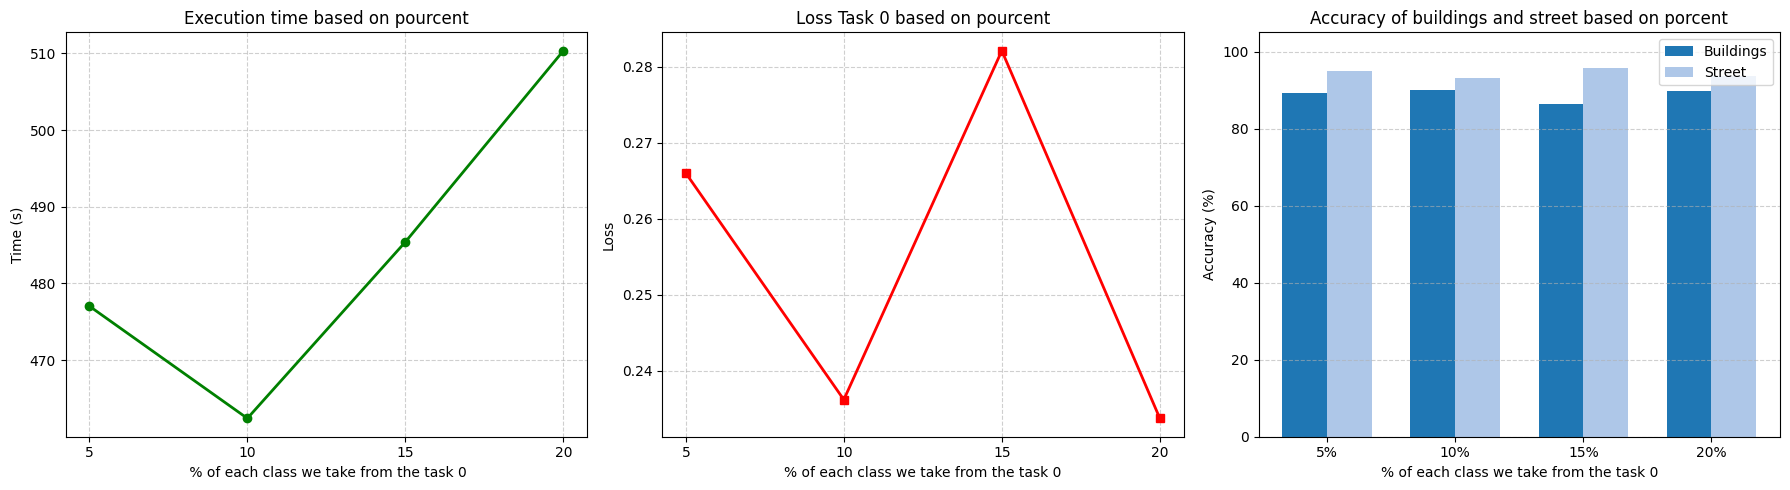

In [47]:
pourcent = [5, 10, 15, 20]  


acc_A = []
acc_B = []
for d in accuracy:
    acc_A.append((d["A_true"] / d["A_tot"] * 100) if d["A_tot"] > 0 else 0.0)
    acc_B.append((d["B_true"] / d["B_tot"] * 100) if d["B_tot"] > 0 else 0.0)


fig, axs = plt.subplots(1, 3, figsize=(18, 5))

#Time 
axs[0].plot(pourcent, time_lst, marker='o', color='g', linestyle='-', linewidth=2)
axs[0].set_title("Execution time based on pourcent")
axs[0].set_xlabel(" % of each class we take from the task 0")
axs[0].set_ylabel("Time (s)")
axs[0].set_xticks(pourcent)
axs[0].grid(True, linestyle='--', alpha=0.6)

# Loss Task 0 
axs[1].plot(pourcent, loss_task0, marker='s', color='r', linestyle='-', linewidth=2)
axs[1].set_title("Loss Task 0 based on pourcent")
axs[1].set_xlabel("% of each class we take from the task 0")
axs[1].set_ylabel("Loss")
axs[1].set_xticks(pourcent)
axs[1].grid(True, linestyle='--', alpha=0.6)

# Accuracy A and B during the train of the task 1
x = np.arange(len(pourcent))  
width = 0.35  # Largeur de chaque barre

bar1 = axs[2].bar(x - width/2, acc_A, width, label='Buildings', color='#1f77b4')
bar2 = axs[2].bar(x + width/2, acc_B, width, label='Street', color='#aec7e8')

axs[2].set_title("Accuracy of buildings and street based on porcent")
axs[2].set_xlabel("% of each class we take from the task 0")
axs[2].set_ylabel("Accuracy (%)")
axs[2].set_xticks(x)
axs[2].set_xticklabels([f"{t}%" for t in pourcent])
axs[2].set_ylim(0, 105) 
axs[2].legend()
axs[2].grid(True, axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()


plt.show()

In [ ]:
### A partir d'ici c'set la partie 2 du cod . Avant ici c'est la partoe 1 du code . La partie 2 se foculise ecxcluisiovement sur les methodes d'entrainement eavec A-GEM . La partie 1 se focalise sur les prerequis pour la constructui des datstatset , dataloader et autrse et surtout sur le continual leanring sans A -GEM

In [48]:


classe = {'buildings' : 0, 'forest' : 1, 'glacier' : 2, 'mountain' : 3, 'sea' : 4, 'street' : 5}
# To do the reverse path
label_to_classname= {0: 'buildings', 1: 'forest', 2: 'glacier', 3: 'mountain', 4: 'sea', 5: 'street'}

class IntelDataset(Dataset):
    def __init__(self, df, transform=None, base_dir=None, label_map=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.base_dir = base_dir # This will now be the task-specific img folder
        self.label_map = label_map # Conversion dictionary, ex: {3: 1, 1: 0}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['image_name']
        label = int(row['label'])

        # No need to get class_name from label_to_classname if base_dir is already specific
        # The base_dir should be something like /content/my_intel_dataset/seg_train/seg_train/df_buildings_sea/img

        # Remapping so the label is 0 or 1 for the binary model
        if self.label_map is not None:
            label = self.label_map[label]

        # Simplified img_path construction
        img_path = os.path.join(self.base_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [49]:
#### GLOBAL PARAMETERS FOR PART 2 ####

NB_EPOCH=3
epochs_per_task=2
memory_size_per_task=300
batch_size=32

classe = {'buildings' : 0, 'forest' : 1, 'glacier' : 2, 'mountain' : 3, 'sea' : 4, 'street' : 5}
device="cuda" if torch.cuda.is_available() else "cpu"

# Mapping for each task to local head indices [0, 1]
task_mappings = {
    0: {0: 0, 4: 1},  # Task 0: Buildings -> 0, Sea -> 1
    1: {1: 0, 3: 1}   # Task 1: Forest -> 0, Mountain -> 1
}

tasks_definition = {
    0: [0, 4],
    1: [1, 3]
}

In [50]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

def create_mapped_loader(df, task_id, root_dir):

    # I use Laura's transform pipeline in my part (2e part)
    ds = IntelDataset(df, transform=transform, base_dir=root_dir, label_map=None)
    return DataLoader(ds, batch_size=32, shuffle=False)

#Dictionary containing the good dataloader for the test
dict_test_loader = {
    0: create_mapped_loader(label_AB_test, 0, path_img_AB_test),
    1: create_mapped_loader(label_CD_test, 1, path_img_CD_test),
}

In [51]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.cluster import KMeans


class EpisodicMemory:
  def __init__(self, max_memories_sample=1000):
    """
    max_memory_sample : the max images to keep for each past task
    """
    self.max_memories_sample=max_memories_sample
    self.memory_dataset=None   # No TensorDataset yet

  def _extract_features(self,model,dataset,device):
    """
    extract the features of the layer just before the last layer
    """
    # switch to eval mode
    model.eval()

    # We take as feature extractor the whole model except the last layer
    backbone = torch.nn.Sequential(*list(model.children())[:-1]).to(device)
    features_list=[]
    temp_loader=DataLoader(dataset, batch_size=64,shuffle=False)

    with torch.no_grad():
      for images, _ in temp_loader:
        images=images.to(device)
        # the features go into the backbone to have the features
        features=backbone(images)
        features = features.view(features.size(0), -1)
        features_list.append(features.cpu().numpy())

    model.train()
    return np.concatenate(features_list, axis=0)

  def KMeans_sample_extractor(self,task_dataset, model=None,device='cuda'):
    """
    We extract the feature to choose the best image for each cluster using KMeans
    """
    budget = min(self.max_memories_sample, len(task_dataset))

    if model is not None:
      print("Extraction of the features with KMeans")
      features=self._extract_features(model,task_dataset,device)

      print(f'We use KMeans with K={budget}')

      # Use of KMEans to create clusters
      kmeans = KMeans(n_clusters=budget, n_init='auto', random_state=42)
      cluster_labels = kmeans.fit_predict(features)
      # the centroids
      centroids = kmeans.cluster_centers_

      # Selection of the best image for each cluster
      selected_indices=[]
      for i in range(budget):
        idx_in_cluster = np.where(cluster_labels == i)[0]
        if len(idx_in_cluster) > 0:
          cluster_features = features[idx_in_cluster]

          # We compute the distances
          distances = np.linalg.norm(cluster_features - centroids[i], axis=1)
          # The best indices
          best_local_idx = np.argmin(distances)
          selected_indices.append(idx_in_cluster[best_local_idx])


      # extraction of the tensors (images,labels) linked to these selected indices
      full_loader = DataLoader(task_dataset, batch_size=len(task_dataset), shuffle=False)
      all_images, all_labels = next(iter(full_loader))

      # Final selected images and labels
      images_from_samples = all_images[selected_indices]
      labels_sample = all_labels[selected_indices]

      print("K-Means ended")

      return images_from_samples,labels_sample


  def store_memories(self,task_dataset,id_task,method="random"):
    """
    extracts a random sample from the task that has just finished
    Method: “random” for the standard random method, “KMeans” for the K-means method
    """
    if method=="KMeans":
      images_from_samples,labels_sample=self.KMeans_sample_extractor(task_dataset,model,device)

    else:
      budget = min(self.max_memories_sample, len(task_dataset))

      # We create a temporary dataloader with batchsize=self.max_memories_sample
      temp_loader=DataLoader(task_dataset, batch_size=budget,shuffle=True)
      images_from_samples,labels_sample = next(iter(temp_loader))

    task_ids = torch.full((len(labels_sample),), id_task, dtype=torch.long)


    if self.memory_dataset is None:

      # Merge the images and the labels in a tensordataset
      self.memory_dataset=TensorDataset(images_from_samples,labels_sample, task_ids)

    else:
      old_labels=self.memory_dataset.tensors[1]
      old_images=self.memory_dataset.tensors[0]
      old_task_ids = self.memory_dataset.tensors[2]

      # We merge the past and the present

      new_images=torch.cat([old_images,images_from_samples] )
      new_labels=torch.cat([old_labels,labels_sample])
      new_task_ids = torch.cat([old_task_ids, task_ids])

      self.memory_dataset=TensorDataset(new_images,new_labels,new_task_ids)

      print(f"-> A-GEM Buffer updated. Total memory size: {len(self.memory_dataset)} images.")



  def get_reference_batch(self, batch_size):
    if self.memory_dataset is None:
      return None

    ref_loader=DataLoader(self.memory_dataset, batch_size=batch_size,shuffle=True)
    return next(iter(ref_loader))


In [52]:
def train_agrem_step(model, optimizer, criterion, current_batch, batch_ref, device, id_task):
    """
    Train the model using A-GEM for one step, handling Multi-Head gradients securely.
    """
    current_imgs, current_labels = current_batch
    current_imgs, current_labels = current_imgs.to(device), current_labels.to(device)


    img_ref, label_ref, task_id_ref = batch_ref
    img_ref, label_ref, task_id_ref = img_ref.to(device), label_ref.to(device), task_id_ref.to(device)

    # 1. Compute g (gradient for the current task)
    optimizer.zero_grad()
    current_output = model(current_imgs, id_task)
    current_loss = criterion(current_output, current_labels)
    current_loss.backward()

    # We replace the 'None by zeros' for more security
    grads = []
    for p in model.parameters():
        if p.requires_grad:
            if p.grad is not None:
                grads.append(p.grad.view(-1).clone())
            else:
                grads.append(torch.zeros_like(p).view(-1))
    g = torch.cat(grads)

    # 2. Compute g_ref (gradient for memory/reference batch)
    optimizer.zero_grad()

    #It prevent problems with the BathNorm (corruption of the memory)
    model.eval()

    # We calculate the loss
    unique_tasks = torch.unique(task_id_ref)
    loss_ref = 0
    for t in unique_tasks:
        mask = (task_id_ref == t)
        img_t = img_ref[mask]
        label_t = label_ref[mask]

        output_t = model(img_t, id_task=t.item())
        loss_t = criterion(output_t, label_t)
        # Pondération de la loss selon le nombre d'images de cette tâche
        loss_ref += loss_t * (img_t.size(0) / img_ref.size(0))

    loss_ref.backward()

    # Return in train mode
    model.train()

    grads_ref = []
    for p in model.parameters():
        if p.requires_grad:
            if p.grad is not None:
                grads_ref.append(p.grad.view(-1).clone())
            else:
                grads_ref.append(torch.zeros_like(p).view(-1))
    g_ref = torch.cat(grads_ref)


    # I use Laura's function to do A-GEM Projection
    g_update=project_gradient(g,g_ref)
    g=g_update

    # 4. Manually update gradients in the model
    optimizer.zero_grad()
    index = 0
    for p in model.parameters():
        if p.requires_grad:
            num_params = p.numel()
            p.grad = g[index:index + num_params].view(p.shape).clone()
            index += num_params

    optimizer.step()
    return current_loss.item()

In [53]:
def train_standard_step(model, optimizer, criterion, current_batch, device, id_task):
  """
  Train the model WITHOUT using A-GEM model for one step.
  """
  current_imgs, current_labels = current_batch
  current_imgs, current_labels = current_imgs.to(device), current_labels.to(device)

  optimizer.zero_grad()
  predictions = model(current_imgs, id_task)
  loss = criterion(predictions, current_labels)
  loss.backward()
  optimizer.step()

  return loss.item()

In [54]:
def evaluate_continual_eval(model, test_loaders, list_of_learned_task, device):
    """
    Function to evaluate the performances : accuracy and loss on the test set
    """
    model.eval()
    results = {}

    with torch.no_grad():
        for id_task in list_of_learned_task:
            specific_test_loader = test_loaders[id_task]
            total_correct = 0
            total_loss = 0.0
            total_samples = 0

            for images, labels in specific_test_loader:
                images, labels = images.to(device), labels.to(device)

                logits = model(images, id_task)
                loss = criterion(logits, labels)

                _, preds = torch.max(logits, dim=1)
                total_correct += (preds == labels).sum().item()
                total_loss += loss.item() * labels.size(0)
                total_samples += labels.size(0)
            #Dict with the performance
            results[id_task] = {
                'acc': total_correct / total_samples,
                'loss': total_loss / total_samples
            }

    model.train()
    return results

In [55]:


def train_agem_global(model, optimizer, criterion, dict_test_loader, device='cuda'):
  """
  Final function to train the model with the A-GEM method (for all the step)
  """

  # Initialize memory buffer to store samples from previous tasks
  buffer_agem = EpisodicMemory(max_memories_sample=memory_size_per_task)
  list_of_learned_task = []
  model.to(device)

  for id_task, classes in tasks_definition.items():
    print(f"\n--- Task {id_task} (Classes: {classes}) ---")

    #We do Local mapping: map original classes to 0 and 1 for the specific task head
    local_map = {classes[0]: 0, classes[1]: 1}

    # We Select only images belonging to the current task classes
    #current_df = label_ABCD_train[label_ABCD_train['label'].isin(classes)]
    current_df = label_ABCD_train[label_ABCD_train['task_id'] == id_task]

    # Determine the correct image base directory for the current task
    if id_task == 0:
        current_task_img_path = path_img_AB_train
    elif id_task == 1:
        current_task_img_path = path_img_CD_train
    else:
        raise ValueError(f"Unknown task ID: {id_task}")


    current_dataset = IntelDataset(
        current_df,
        transform=transform,
        label_map=None,
        base_dir=current_task_img_path # Use the task-specific path here
    )
    current_loader = DataLoader(current_dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(1, epochs_per_task + 1):
      model.train()
      for imgs, labels in tqdm(current_loader, desc=f"Epoch {epoch}"):
        # Get a reference batch from the memory buffer
        batch_ref = buffer_agem.get_reference_batch(batch_size=batch_size)

        if batch_ref is not None:

          imgs_ref, labels_ref, task_ids_ref = batch_ref

          # Use A-GEM step if we have samples from previous tasks

          train_agrem_step(model, optimizer, criterion, (imgs, labels), (imgs_ref, labels_ref,task_ids_ref), device, id_task)
        else:
          # Standard training for the first task
          train_standard_step(model, optimizer, criterion, (imgs, labels), device, id_task)

    # Save some images to the buffer after finishing the task
    buffer_agem.store_memories(current_dataset,id_task=id_task ,method='random')
    list_of_learned_task.append(id_task)

    # Evaluate the model on all tasks learned so far
    results = evaluate_continual_eval(model, dict_test_loader, list_of_learned_task, device)
    print(f"\n Result after task {id_task} :")
    for t_id, metrics in results.items():
      print(f"   * Task {t_id} -> Accuracy: {metrics['acc']*100:.2f}% | Loss: {metrics['loss']:.4f}")

In [56]:
# Clear GPU cache
torch.cuda.empty_cache()

label_ABCD_train=pd.concat([label_AB_train,label_CD_train], ignore_index=True)
label_ABCD_train.to_csv(os.path.join(dataset_train_path, 'label_train_ABCD.csv'), index=False)

label_ABCD_test=pd.concat([label_AB_test, label_CD_test], ignore_index=True)
label_ABCD_test.to_csv(os.path.join(dataset_test_path, 'label_test_ABCD.csv'), index=False)

class MultiHeadResNet(nn.Module):
    def __init__(self, original_resnet):
        super(MultiHeadResNet, self).__init__()
        # Backbone: all layers except the final FC
        self.features = nn.Sequential(*list(original_resnet.children())[:-1])
        # One head (Linear layer) per task, each outputting 2 classes
        self.heads = nn.ModuleList([nn.Linear(512, 2), nn.Linear(512, 2)])

    def forward(self, x, id_task):
        # Changed parameter name task_id to id_task to fix the TypeError
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.heads[id_task](x)
        return x

# Initialize model
device = "cuda" if torch.cuda.is_available() else "cpu"
base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model = MultiHeadResNet(base_model).to(device)

criterion = nn.CrossEntropyLoss()
# Optimizer tracks all parameters; A-GEM step handles the gradient logic
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# Start training
train_agem_global(model, optimizer, criterion, dict_test_loader, device)


--- Task 0 (Classes: [0, 4]) ---


Epoch 2: 100%|██████████| 143/143 [01:51<00:00,  1.28it/s]



 Result after task 0 :
   * Task 0 -> Accuracy: 92.11% | Loss: 0.1905

--- Task 1 (Classes: [1, 3]) ---


Epoch 2: 100%|██████████| 154/154 [04:26<00:00,  1.73s/it]


-> A-GEM Buffer updated. Total memory size: 600 images.

 Result after task 1 :
   * Task 0 -> Accuracy: 92.11% | Loss: 0.1874
   * Task 1 -> Accuracy: 88.59% | Loss: 0.2976



--- Task 0 (Classes: [0, 4]) ---


Epoch 6: 100%|██████████| 70/70 [00:37<00:00,  1.87it/s]



 Result after task 0 :
   * Task 0 -> Precision: 46.15% | Loss: 0.0172

--- Task 1 (Classes: [1, 3]) ---


Epoch 6: 100%|██████████| 75/75 [01:01<00:00,  1.23it/s]


-> A-GEM Buffer updated. Total memory size: 100 images.

 Result after task 1 :
   * Task 0 -> Precision: 46.15% | Loss: 0.0624
   * Task 1 -> Precision: 52.55% | Loss: 0.0190
